<a href="https://colab.research.google.com/github/MIL-Project2/DR-DT/blob/main/Occupancy_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Set your user info (Git is already installed!)
!git config --global user.email "jwas0006@student.monash.edu"
!git config --global user.name "MIL-Project2"

# 2. Clone your repo (if you haven't already)
!git clone https://github.com/MIL-Project2/DR-DT.git
%cd DR-DT

# 3. Make your changes or add new files...

# 4. Push back to GitHub
!git add .
!git commit -m "Updated from Colab"

# 5. Push using your Personal Access Token (paste it when prompted for a password)
!git push

Cloning into 'DR-DT'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 24 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 902.07 KiB | 10.49 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/DR-DT/DR-DT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
df = pd.read_csv('Occupancy-Prediction_Generated_Ver_1.0.csv', delimiter=',')

In [9]:
# ── Missing Values, Data Types & Duplicates ──────────────────────────────────
print("=== DATA AUDIT REPORT ===")
column_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(column_info)
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nStatistical Summary:")
display(df.describe().round(2))

=== DATA AUDIT REPORT ===


,Data Type,Non-Null Count,Missing Values,Missing (%)
deviceid,int64,1000,0,0.0
floorspaceid,object,1000,0,0.0
headcount,int64,1000,0,0.0
timestamp,object,1000,0,0.0
temperature,float64,1000,0,0.0
humidity,float64,1000,0,0.0
co2,float64,1000,0,0.0
hour,int64,1000,0,0.0
day_of_week,int64,1000,0,0.0
occupancy_lag_5min,int64,1000,0,0.0



Duplicate Rows: 0

Statistical Summary:


,deviceid,headcount,temperature,humidity,co2,hour,day_of_week,occupancy_lag_5min,occupancy_lag_10min,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min
count,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,56923747.0,1.42,20.59,58.47,457.72,11.22,3.41,0.31,0.31,0.31,0.31,457.69,20.59
std,0.0,2.63,1.78,5.51,72.04,6.95,1.83,0.46,0.46,0.46,0.35,57.24,1.75
min,56923747.0,0.00,17.24,42.73,317.59,0.00,0.00,0.00,0.00,0.00,0.00,346.21,17.69
25%,56923747.0,0.00,18.90,54.14,403.22,5.00,2.00,0.00,0.00,0.00,0.00,413.20,18.86
50%,56923747.0,0.00,20.53,58.47,436.76,11.00,4.00,0.00,0.00,0.00,0.33,445.07,20.49
75%,56923747.0,2.00,22.32,62.52,507.63,17.00,5.00,1.00,1.00,1.00,0.67,495.78,22.31
max,56923747.0,15.00,23.85,73.22,666.50,23.00,6.00,1.00,1.00,1.00,1.00,630.73,23.56


## **Exploratory Data Analysis (EDA)**

This section consolidates and extends the EDA. The analysis is structured around two research questions:

- **Q1:** What is the distribution of the target variable “headcount"?
- **Q2:** Which numerical features are most strongly correlated with “headcount”?

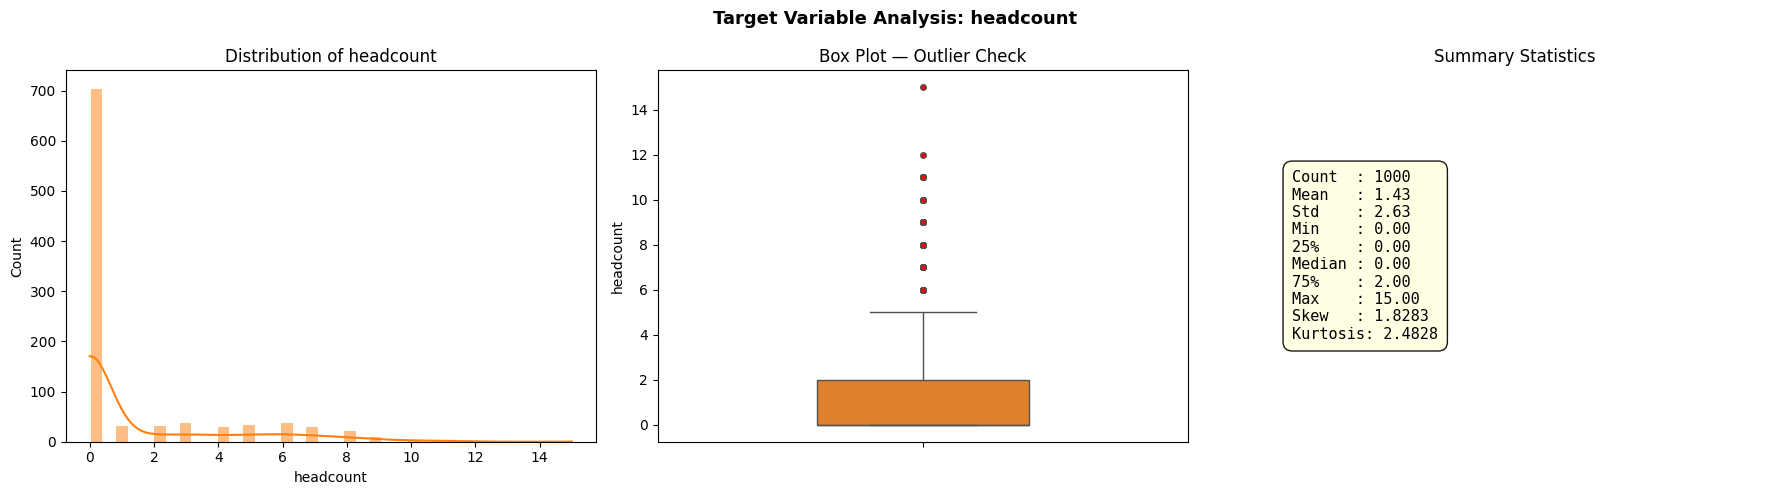

Skewness : 1.8283  (|skew| < 0.5 = approx. normal)
Kurtosis : 2.4828
IQR-based outliers : 120 (12.0%)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
sns.histplot(df['headcount'], kde=True, ax=axes[0], color='tab:orange', edgecolor='white')
axes[0].set_title('Distribution of headcount')
axes[0].set_xlabel('headcount'); axes[0].set_ylabel('Count')

# Box plot — outlier check
sns.boxplot(y=df['headcount'], ax=axes[1], color='tab:orange', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[1].set_title('Box Plot — Outlier Check')
axes[1].set_ylabel('headcount')

# Summary statistics panel
desc = df['headcount'].describe()
lines = [f"Count  : {desc['count']:.0f}",
         f"Mean   : {desc['mean']:.2f}",
         f"Std    : {desc['std']:.2f}",
         f"Min    : {desc['min']:.2f}",
         f"25%    : {desc['25%']:.2f}",
         f"Median : {desc['50%']:.2f}",
         f"75%    : {desc['75%']:.2f}",
         f"Max    : {desc['max']:.2f}",
         f"Skew   : {df['headcount'].skew():.4f}",
         f"Kurtosis: {df['headcount'].kurtosis():.4f}"]
axes[2].axis('off')
axes[2].text(0.08, 0.5, '\n'.join(lines), transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('Summary Statistics')

plt.suptitle('Target Variable Analysis: headcount', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Skewness : {df['headcount'].skew():.4f}  (|skew| < 0.5 = approx. normal)")
print(f"Kurtosis : {df['headcount'].kurtosis():.4f}")
q1, q3 = df['headcount'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['headcount'] < q1 - 1.5*iqr) | (df['headcount'] > q3 + 1.5*iqr)]
print(f"IQR-based outliers : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Pearson Correlation with Headcount (sorted by absolute value):
                           Correlation
co2                             0.8365
occupancy_rolling_15min         0.6806
co2_rolling_15min               0.6707
occupancy_lag_15min             0.3505
temperature_rolling_15min      -0.1084
humidity                        0.0560
temperature                    -0.0459


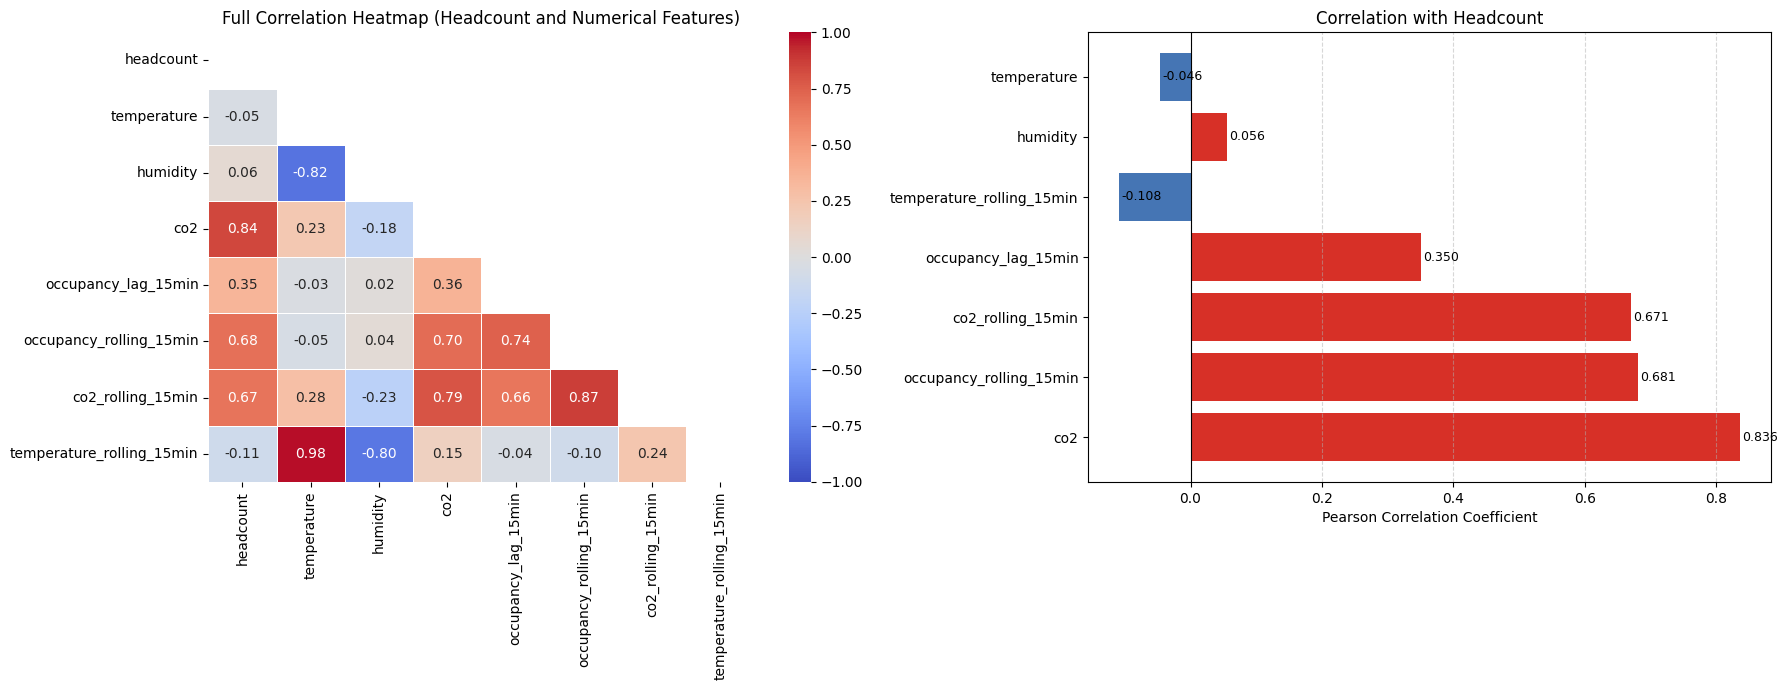

In [12]:
import numpy as np
# Identify numerical features relevant for correlation with 'headcount'
numerical_features = [
    'temperature', 'humidity', 'co2',
    'occupancy_lag_15min', 'occupancy_rolling_15min', 'co2_rolling_15min',
    'temperature_rolling_15min'
]

# Ensure 'headcount' is included for correlation calculation
cols_for_corr = ['headcount'] + numerical_features

# Calculate correlation matrix
corr_matrix_headcount = df[cols_for_corr].corr()

# Correlation with headcount (sorted by absolute value)
headcount_corr = corr_matrix_headcount['headcount'].drop('headcount').sort_values(key=abs, ascending=False)
print("Pearson Correlation with Headcount (sorted by absolute value):")
print(headcount_corr.to_frame('Correlation').round(4))

# Visualize correlations with heatmap and bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap (only for the selected numerical features and headcount)
mask = np.triu(np.ones_like(corr_matrix_headcount, dtype=bool))
sns.heatmap(corr_matrix_headcount, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Full Correlation Heatmap (Headcount and Numerical Features)', fontsize=12)

# Bar chart of correlations with headcount
colors_headcount = ['#d73027' if v > 0 else '#4575b4' for v in headcount_corr.values]
axes[1].barh(headcount_corr.index, headcount_corr.values, color=colors_headcount)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Headcount', fontsize=12)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(headcount_corr.values):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight — (Correlation Analysis with `headcount`):**  
The heatmap and correlation bar chart reveal a **strong positive linear relationship** between `co2` and `headcount` (Pearson r ≈ 0.84). This suggests that `co2` levels are a significant indicator of `headcount`.

Other features like `occupancy_rolling_15min` (Pearson r ≈ 0.68) and `co2_rolling_15min` (Pearson r ≈ 0.67) also show moderately strong positive correlations with `headcount`. `occupancy_lag_15min` has a weaker positive correlation (Pearson r ≈ 0.35).

Conversely, `temperature_rolling_15min`, `humidity`, and `temperature` exhibit very weak correlations with `headcount`, suggesting they are not strong linear predictors of headcount in this dataset.

---
## **Data Cleaning & Preprocessing**

This section outlines the data cleaning and preprocessing steps necessary to prepare the `df` DataFrame for machine learning tasks. Building upon the initial data audit and EDA, this stage focuses on:

1.  **Timestamp Conversion & Feature Engineering**: Converting the `timestamp` column to datetime objects and extracting useful time-based features (e.g., hour of day, day of week) that might influence occupancy.
2.  **Outlier Strategy**: Deciding on an approach to handle the outliers identified in the `headcount` target variable and other numerical features.
3.  **Feature Scaling**: Applying appropriate scaling techniques to numerical features to ensure they are on a comparable scale for various machine learning algorithms.

In [13]:
# Convert 'timestamp' to datetime and extract time-based features
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Display the first few rows with the new features
display(df[['timestamp', 'hour', 'day_of_week', 'headcount']].head())

/tmp/ipykernel_2273/2629267458.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


,timestamp,hour,day_of_week,headcount
0,2026-01-01 00:00:00,0,3,0
1,2026-01-01 00:15:00,0,3,0
2,2026-01-01 00:30:00,0,3,0
3,2026-01-01 00:45:00,0,3,0
4,2026-01-01 01:00:00,1,3,0


### **Outlier Strategy for `headcount`**

Given the identified outliers in the `headcount` target variable (12% as per initial analysis), a common strategy is to cap these outliers using the Interquartile Range (IQR) method. This approach replaces values above the upper bound and below the lower bound with the respective bound values, preventing extreme values from disproportionately influencing model training while retaining all data points.

Original headcount min: 0, max: 15
Outlier bounds: Lower = -3.00, Upper = 5.00
Capped headcount min: 0, max: 5


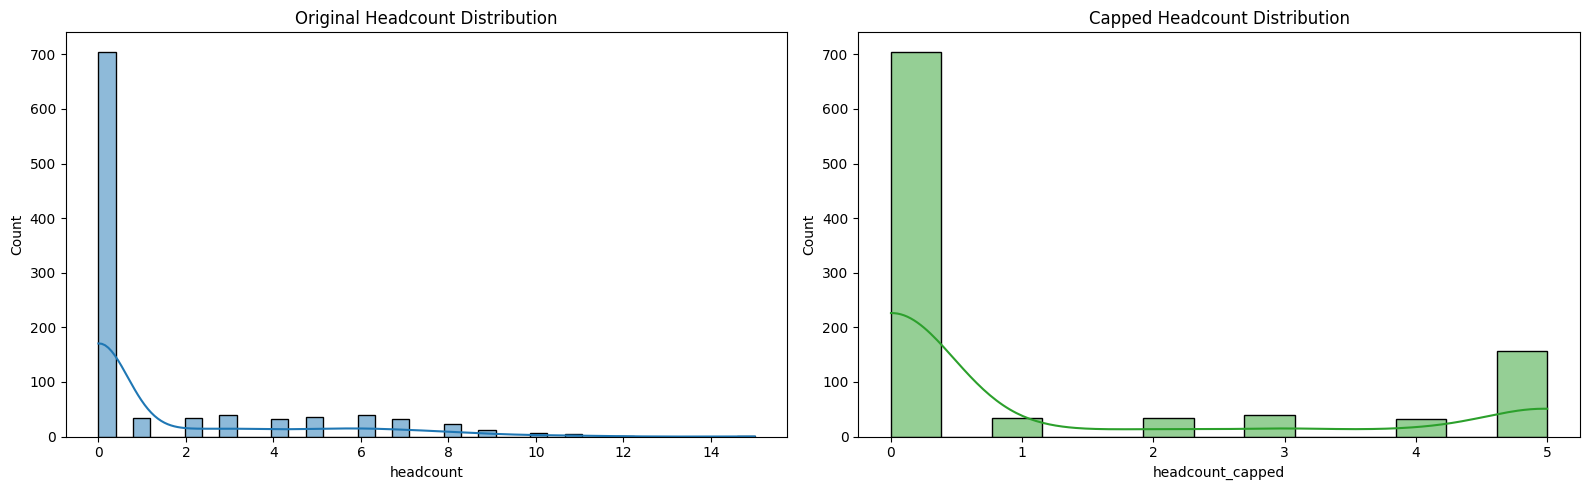

In [14]:
# Calculate IQR for 'headcount'
Q1 = df['headcount'].quantile(0.25)
Q3 = df['headcount'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers in 'headcount'
df['headcount_capped'] = df['headcount'].clip(lower=lower_bound, upper=upper_bound)

print(f"Original headcount min: {df['headcount'].min()}, max: {df['headcount'].max()}")
print(f"Outlier bounds: Lower = {lower_bound:.2f}, Upper = {upper_bound:.2f}")
print(f"Capped headcount min: {df['headcount_capped'].min()}, max: {df['headcount_capped'].max()}")

# Optionally, visualize the distribution after capping
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['headcount'], kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Original Headcount Distribution')

sns.histplot(df['headcount_capped'], kde=True, ax=axes[1], color='tab:green')
axes[1].set_title('Capped Headcount Distribution')

plt.tight_layout()
plt.show()

### **Feature Scaling**

Feature scaling is a critical preprocessing step for many machine learning algorithms, especially those that rely on distance calculations (e.g., K-Nearest Neighbors, Support Vector Machines) or gradient descent (e.g., Logistic Regression, Neural Networks). It ensures that all features contribute equally to the model's performance and prevents features with larger numerical ranges from dominating the learning process.

Here, we will apply **Standard Scaling** (`StandardScaler`) to numerical features. This method transforms the data to have a mean of 0 and a standard deviation of 1, effectively standardizing the range of each feature.

In [15]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features for scaling
# Exclude 'headcount' and 'headcount_capped' as they are target/capped target
# 'timestamp' is a datetime object, 'deviceid', 'floorspaceid' are categorical/identifier

numerical_cols_to_scale = [
    'temperature', 'humidity', 'co2',
    'occupancy_lag_15min', 'occupancy_rolling_15min', 'co2_rolling_15min',
    'temperature_rolling_15min', 'hour', 'day_of_week'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Numerical features successfully scaled.")
display(df[numerical_cols_to_scale + ['headcount', 'headcount_capped']].head())

Numerical features successfully scaled.


,temperature,humidity,co2,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min,hour,day_of_week,headcount,headcount_capped
0,0.709394,0.300011,-0.257401,-0.673415,-0.902167,-0.323505,0.716389,-1.615910,-0.222531,0,0
1,0.743150,-0.902735,-0.844767,-0.673415,-0.902167,-1.062684,0.753165,-1.615910,-0.222531,0,0
2,0.394338,-0.804626,-1.014352,-0.673415,-0.902167,-1.276121,0.398722,-1.615910,-0.222531,0,0
3,0.411216,-0.255941,-0.702960,-0.673415,-0.902167,-1.074396,0.524492,-1.615910,-0.222531,0,0
4,0.473102,-0.699250,0.011351,-0.673415,-0.902167,-0.715171,0.433023,-1.471889,-0.222531,0,0


### **Inspection-only Correlation Heatmap for Scaled Features**

For visualization purposes in an EDA Correlation Heatmap, we can directly use the preprocessed `df` DataFrame which now contains scaled numerical features and the `headcount_capped` target variable. This section serves to clarify that a separate 'inspection-only' copy (`df_inspect`) is not strictly necessary for this dataset, as the primary `df` has already undergone relevant scaling suitable for correlation analysis.

Key considerations for this dataset's correlation visualization:
- **Numerical Features**: The `temperature`, `humidity`, `co2`, `occupancy_lag_15min`, `occupancy_rolling_15min`, `co2_rolling_15min`, `temperature_rolling_15min`, `hour`, and `day_of_week` features have already been scaled using `StandardScaler` in the main DataFrame.
- **Target Variable**: We will use `headcount_capped` for correlation analysis to account for outlier handling.
- **Categorical Features**: `deviceid` and `floorspaceid` are categorical. If they were to be included in a numerical correlation heatmap, they would require appropriate encoding (e.g., One-Hot Encoding) beforehand. However, for now, we focus on the numerical relationships.

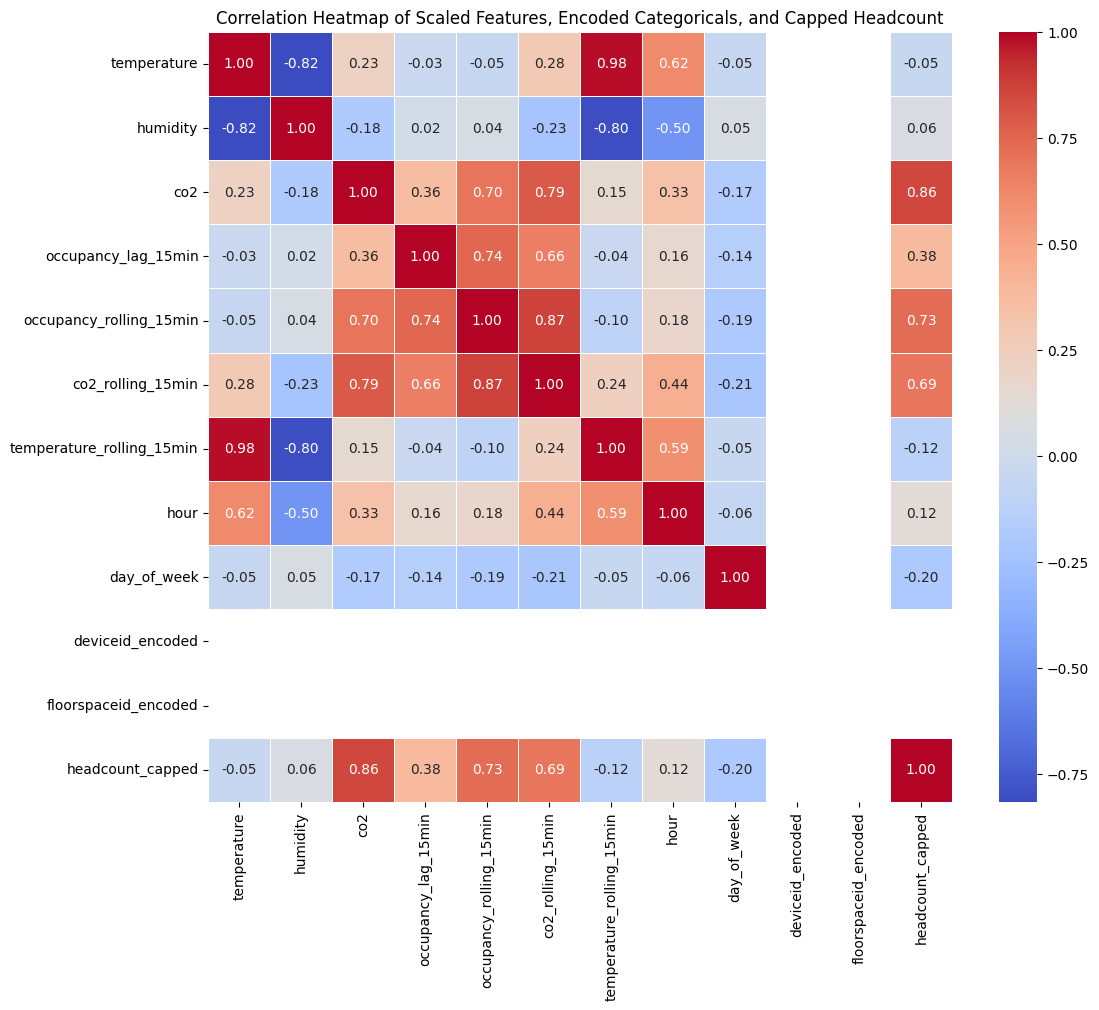

Inspection-only correlation heatmap generated.

Headcount capped correlation with other features (sorted by absolute value):
                           Correlation
co2                             0.8561
occupancy_rolling_15min         0.7290
co2_rolling_15min               0.6882
occupancy_lag_15min             0.3782
day_of_week                    -0.1980
hour                            0.1219
temperature_rolling_15min      -0.1156
humidity                        0.0590
temperature                    -0.0457
deviceid_encoded                   NaN
floorspaceid_encoded               NaN


In [16]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the DataFrame for inspection-only encoding of categorical features
df_inspect_corr = df.copy()

# Encode categorical features for correlation visualization
# Note: LabelEncoder is used for simplicity in this inspection, but OneHotEncoder
# would be more appropriate for model training for nominal categories.
le_device = LabelEncoder()
df_inspect_corr['deviceid_encoded'] = le_device.fit_transform(df_inspect_corr['deviceid'])

le_floorspace = LabelEncoder()
df_inspect_corr['floorspaceid_encoded'] = le_floorspace.fit_transform(df_inspect_corr['floorspaceid'])

# Define all features to include in the correlation heatmap
# This includes the already scaled numerical features, the capped target, and encoded categoricals
features_for_heatmap = numerical_cols_to_scale + ['deviceid_encoded', 'floorspaceid_encoded', 'headcount_capped']

# Calculate the correlation matrix
corr_matrix_inspect = df_inspect_corr[features_for_heatmap].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_inspect, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Scaled Features, Encoded Categoricals, and Capped Headcount')
plt.show()

print("Inspection-only correlation heatmap generated.")
print("\nHeadcount capped correlation with other features (sorted by absolute value):")
print(corr_matrix_inspect['headcount_capped'].drop('headcount_capped').sort_values(key=abs, ascending=False).to_frame('Correlation').round(4))

---
## **Model Development, Training, and Evaluation**

This section presents the complete machine learning pipeline for Predicting `headcount`. All preprocessing from previous section (encoding, scaling) is re-applied **inside scikit-learn pipelines** in this section — encoders and scalers are fitted only on the training data, ensuring there is no information leakage from the test set.

For each task, the workflow follows four consistent stages:
- **(a)** Feature selection and 80/20 train-test split
- **(b)** Baseline model training and diagnostic evaluation
- **(c)** Baseline model comparison
- **(d)** Hyperparameter tuning via Bayesian optimisation (Optuna TPE) with 5-fold cross-validation
- **(e)** Baseline vs tuned performance comparison and best model identification

## **Regression Task: Predicting `headcount`**


### **Modelling Approach**
Since `headcount` is a continuous numerical variable, this is a **supervised regression problem**. Five model families are compared:

| # | Model | Type |
|---|---|---|
| 1 | Support Vector Machine (SVM) | Linear |
| 2 | Random Forest Regressor | Ensemble (Bagging) |
| 3 | Neural Network Regressor (MLP) | Deep learning |

Models are evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, **R² Score**, and **5-fold cross-validation R²**, to assess both accuracy and generalisation.

In [18]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR # Added SVR for Support Vector Machine
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded. Optuna version:', optuna.__version__)

Libraries loaded. Optuna version: 4.9.0


In [19]:
# (a) Feature selection and 80/20 train-test split

# Define target variable (y) and features (X)
y = df['headcount_capped']

# Exclude 'timestamp', original 'headcount', and identifier columns 'deviceid', 'floorspaceid'
# The numeric features are already scaled in df
features = ['temperature', 'humidity', 'co2',
            'occupancy_lag_15min', 'occupancy_rolling_15min', 'co2_rolling_15min',
            'temperature_rolling_15min', 'hour', 'day_of_week']

X = df[features]

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFeatures (X) selected:")
print(features)
print("\nTarget variable (y): 'headcount_capped'")

X_train shape: (800, 9)
X_test shape: (200, 9)
y_train shape: (800,)
y_test shape: (200,)

Features (X) selected:
['temperature', 'humidity', 'co2', 'occupancy_lag_15min', 'occupancy_rolling_15min', 'co2_rolling_15min', 'temperature_rolling_15min', 'hour', 'day_of_week']

Target variable (y): 'headcount_capped'


In [21]:
# (b) Baseline model training and diagnostic evaluation

# Initialize baseline models as per the modelling approach
baseline_models = {
    'Support Vector Regressor': SVR(),
    'Random Forest Regressor': RandomForestRegressor(random_state=RANDOM_STATE),
    'MLP Regressor': MLPRegressor(random_state=RANDOM_STATE)
}

print("Baseline models initialized:")
for name, model in baseline_models.items():
    print(f"- {name}: {model}")

Baseline models initialized:
- Support Vector Regressor: SVR()
- Random Forest Regressor: RandomForestRegressor(random_state=42)
- MLP Regressor: MLPRegressor(random_state=42)


In [22]:
# (c) Train and evaluate baseline models

results = []

for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate performance
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"  {name} - Training MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f}")
    print(f"  {name} - Test MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f}")

    results.append({
        'Model': name,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))



Training Support Vector Regressor...
  Support Vector Regressor - Training MAE: 0.3051, RMSE: 0.5921, R2: 0.9006
  Support Vector Regressor - Test MAE: 0.3502, RMSE: 0.6309, R2: 0.9043

Training Random Forest Regressor...
  Random Forest Regressor - Training MAE: 0.0988, RMSE: 0.2392, R2: 0.9838
  Random Forest Regressor - Test MAE: 0.2674, RMSE: 0.6413, R2: 0.9011

Training MLP Regressor...
  MLP Regressor - Training MAE: 0.3147, RMSE: 0.5772, R2: 0.9056
  MLP Regressor - Test MAE: 0.3435, RMSE: 0.6163, R2: 0.9086


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Support Vector Regressor,0.3051,0.3502,0.5921,0.6309,0.9006,0.9043
1,Random Forest Regressor,0.0988,0.2674,0.2392,0.6413,0.9838,0.9011
2,MLP Regressor,0.3147,0.3435,0.5772,0.6163,0.9056,0.9086


## Resources

### Key Observations from Baseline Models:

| Model                      | Train MAE | Test MAE | Train RMSE | Test RMSE | Train R2 | Test R2 |
|:---------------------------|:----------|:---------|:-----------|:----------|:---------|:--------|
| Support Vector Regressor   | 0.3051    | 0.3502   | 0.5921     | 0.6309    | 0.9006   | 0.9043  |
| Random Forest Regressor    | 0.0988    | 0.2674   | 0.2392     | 0.6413    | 0.9838   | 0.9011  |
| MLP Regressor              | 0.3147    | 0.3435   | 0.5772     | 0.6163    | 0.9056   | 0.9086  |

**Detailed Observations:**

*   **MLP Regressor** shows the best generalization performance with the lowest Test MAE (0.3435) and Test RMSE (0.6163), and the highest Test R2 (0.9086). Its training and test scores are also quite close, suggesting less overfitting compared to Random Forest.
*   **Random Forest Regressor** achieves a very high R2 on the training set (0.9838) but shows a noticeable drop on the test set (0.9011). This indicates some degree of overfitting, which is common for tree-based ensemble models without hyperparameter tuning.
*   **Support Vector Regressor** performs reasonably well, with good R2 scores on both training (0.9006) and test (0.9043) sets, and its performance is quite consistent, showing less variance between training and testing than Random Forest.

Based on these initial baseline results, the MLP Regressor currently appears to be the most promising model in terms of generalization to unseen data. The Random Forest Regressor, despite high training performance, exhibits signs of overfitting that could potentially be mitigated with hyperparameter tuning.

### **Baseline Model Training & Diagnostic Evaluation**

Five regression models are trained on the same preprocessing pipeline: **Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and Neural Network (MLP)**.

For each model, the diagnostic engine below reports and visualises:
- **Training performance:** R², RMSE, and MAE on the 800-sample training split.
- **Validation performance:** Mean 5-fold cross-validation R² and RMSE — the primary measure of generalisation.
- **Test performance:** R², RMSE, and MAE on the held-out 200-sample test set.

Three diagnostic plots are generated per model:
1. **Loss/Learning Curve** — shows how RMSE evolves with training size (or boosting iterations/epochs for GBM/NN). A healthy model shows training and validation curves converging.
2. **Actual vs Predicted Scatter** — test-set predictions plotted against ground truth. Points close to the red diagonal indicate accurate predictions.
3. **Residual Plot** — residuals (actual minus predicted) plotted against predictions. A well-fitted model shows residuals randomly scattered around zero with no systematic patterns.


Generating diagnostic plots for Support Vector Regressor...


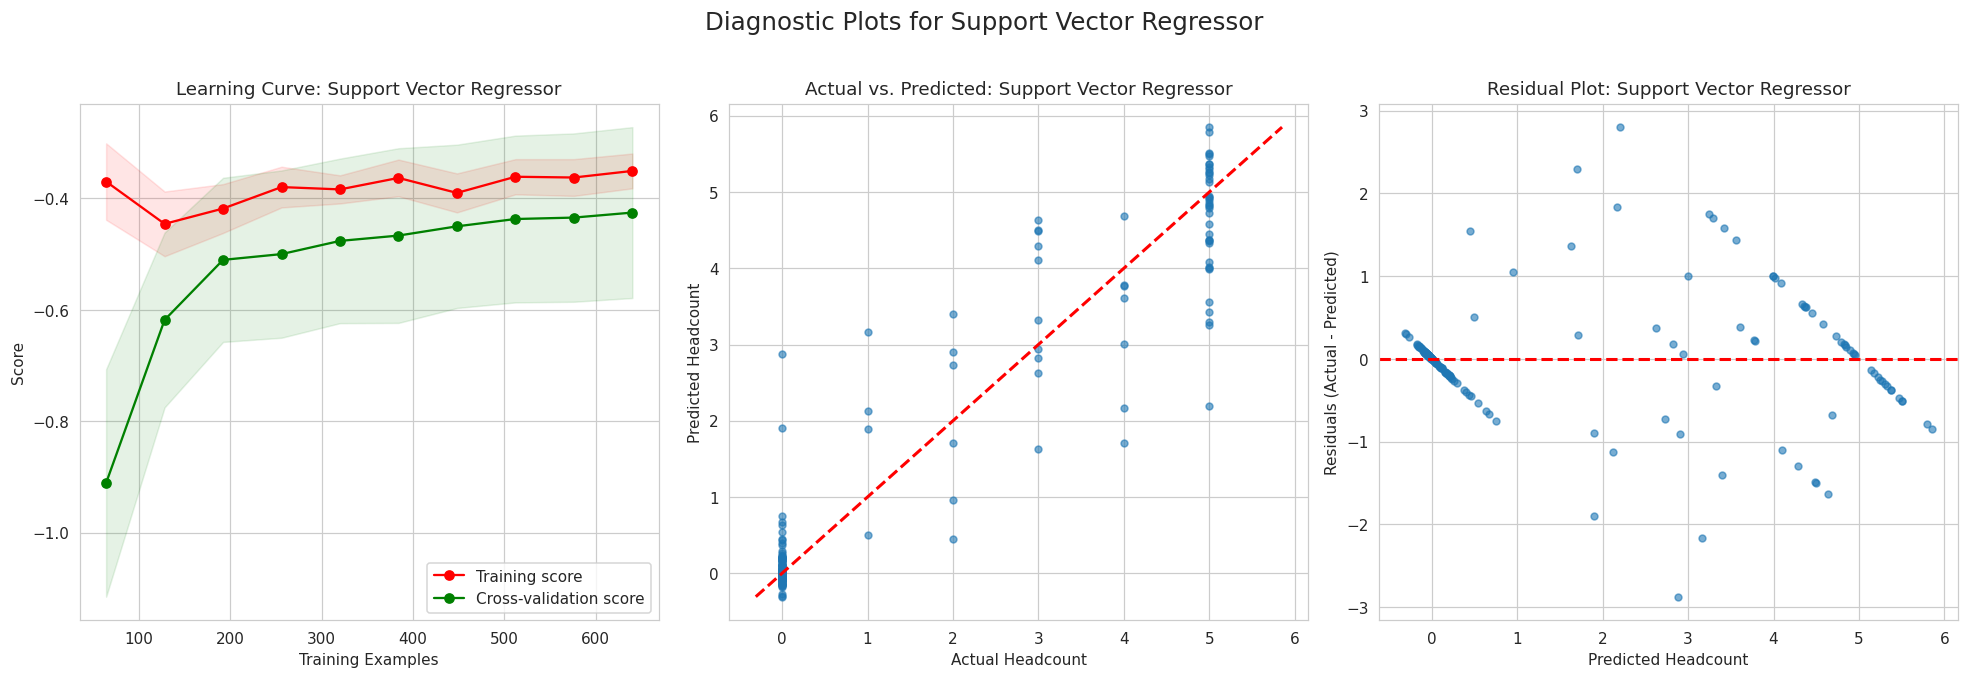


Generating diagnostic plots for Random Forest Regressor...


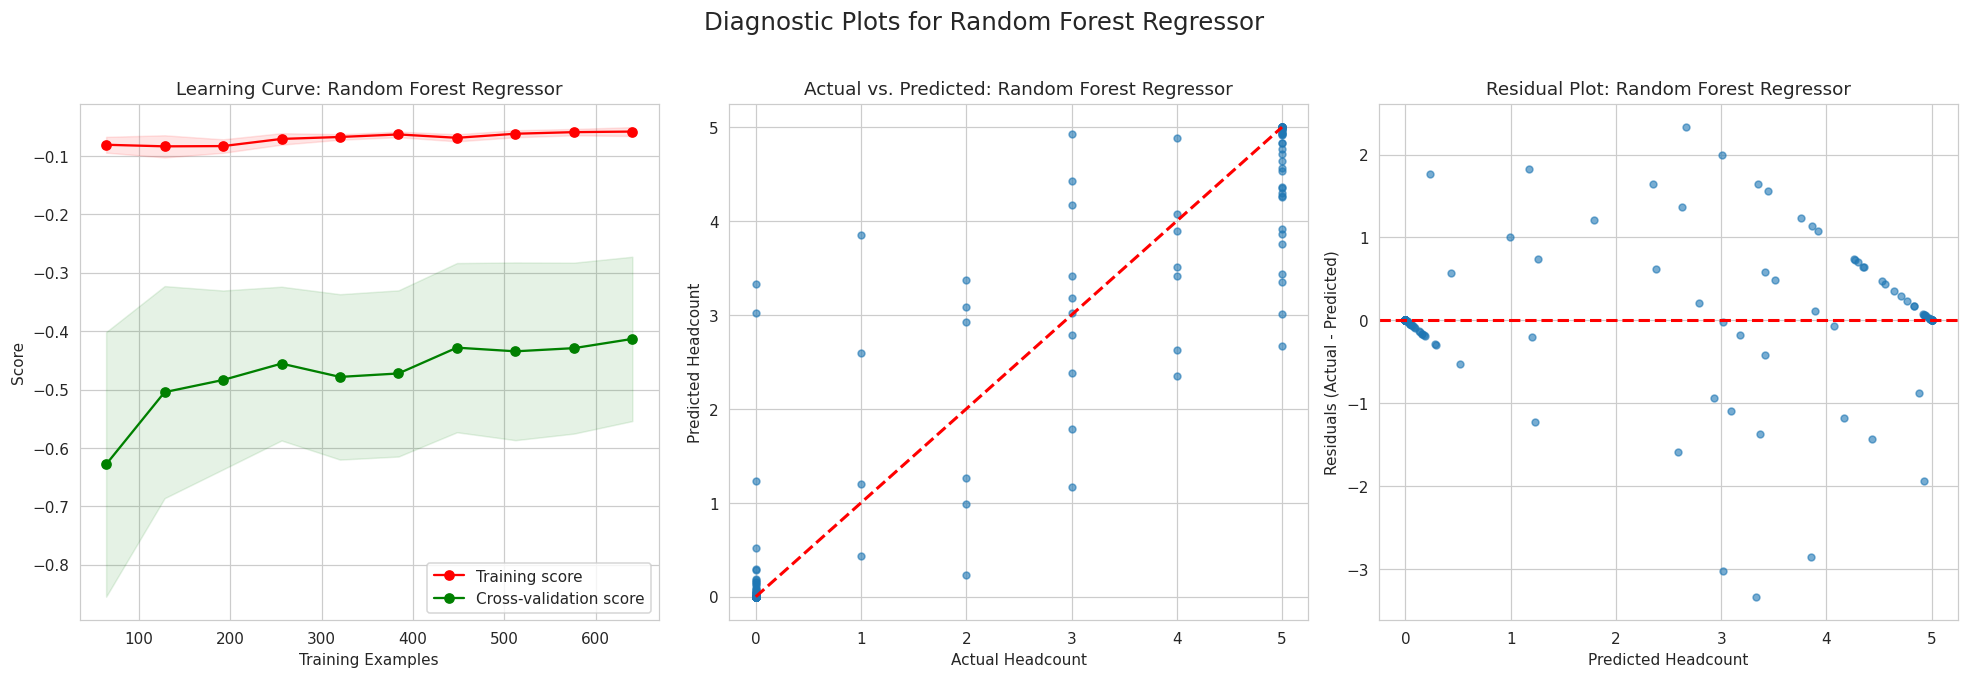


Generating diagnostic plots for MLP Regressor...


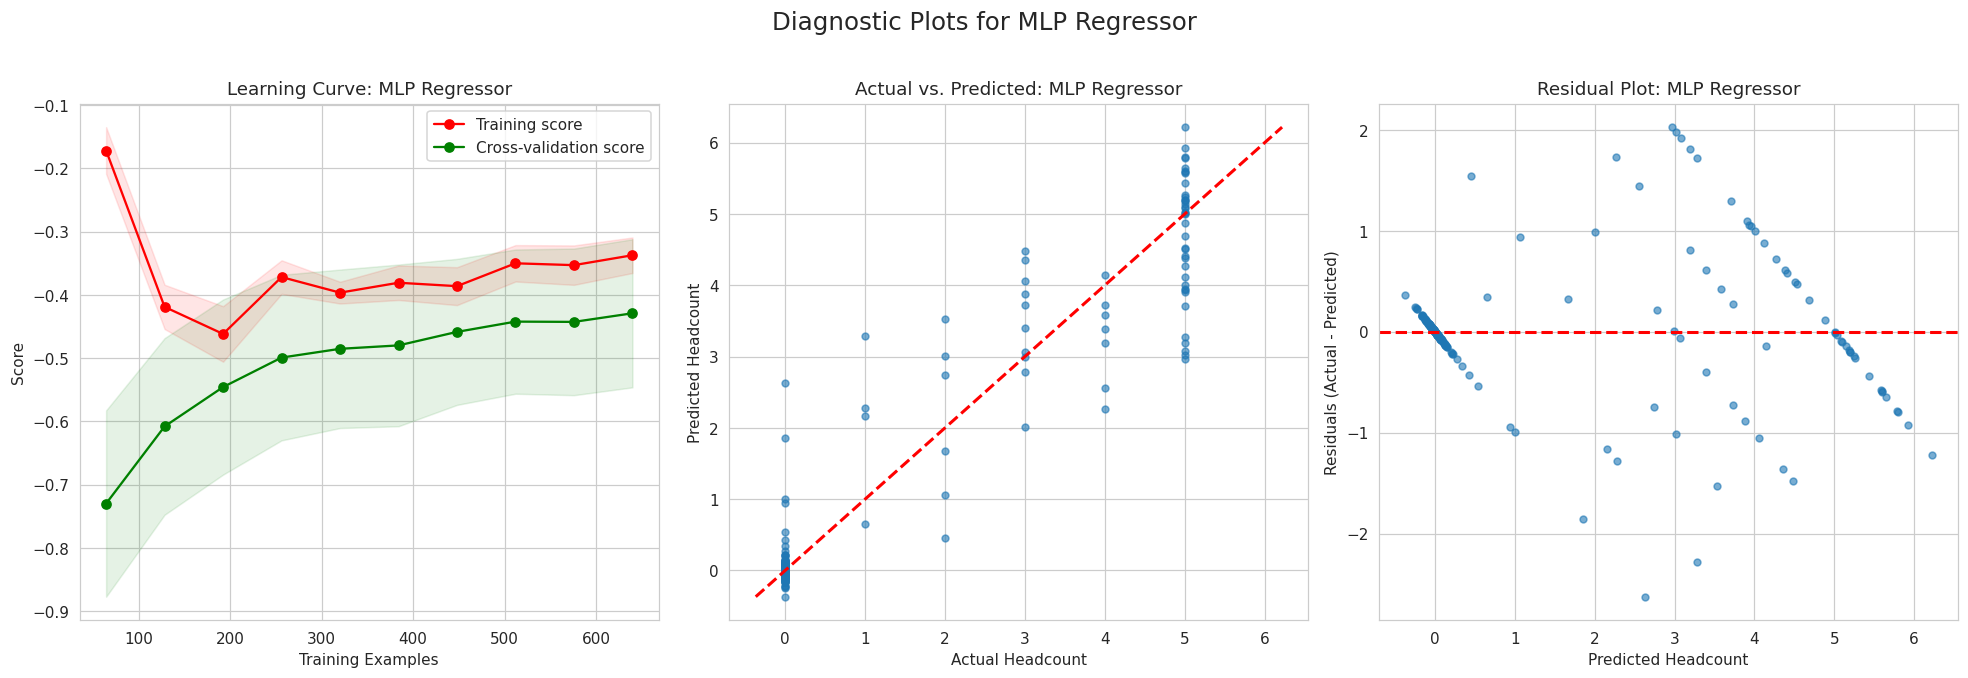

In [24]:
def plot_diagnostics(model, name, X_train, y_train, X_test, y_test, y_test_pred, scoring='neg_mean_squared_error'):
    fig = plt.figure(figsize=(18, 6))
    gs = gridspec.GridSpec(1, 3, figure=fig)

    # 1. Learning Curve
    ax0 = fig.add_subplot(gs[0, 0])
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring=scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    ax0.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax0.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    ax0.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    ax0.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    ax0.set_title(f'Learning Curve: {name}')
    ax0.set_xlabel("Training Examples")
    ax0.set_ylabel("Score") # This will be negative MSE if scoring='neg_mean_squared_error'
    ax0.legend(loc="best")
    ax0.grid(True)

    # 2. Actual vs. Predicted Scatter Plot
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.scatter(y_test, y_test_pred, alpha=0.6, s=20)
    max_val = max(y_test.max(), y_test_pred.max())
    min_val = min(y_test.min(), y_test_pred.min())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2) # Diagonal line
    ax1.set_title(f'Actual vs. Predicted: {name}')
    ax1.set_xlabel('Actual Headcount')
    ax1.set_ylabel('Predicted Headcount')
    ax1.grid(True)

    # 3. Residual Plot
    ax2 = fig.add_subplot(gs[0, 2])
    residuals = y_test - y_test_pred
    ax2.scatter(y_test_pred, residuals, alpha=0.6, s=20)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_title(f'Residual Plot: {name}')
    ax2.set_xlabel('Predicted Headcount')
    ax2.set_ylabel('Residuals (Actual - Predicted)')
    ax2.grid(True)

    plt.suptitle(f'Diagnostic Plots for {name}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


for name, model in baseline_models.items():
    print(f"\nGenerating diagnostic plots for {name}...")
    # Ensure model is refitted in case it's a fresh run or an estimator that needs refitting
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    plot_diagnostics(model, name, X_train, y_train, X_test, y_test, y_test_pred)
